## Clustering
Group similar data points without pre-defined LABELS

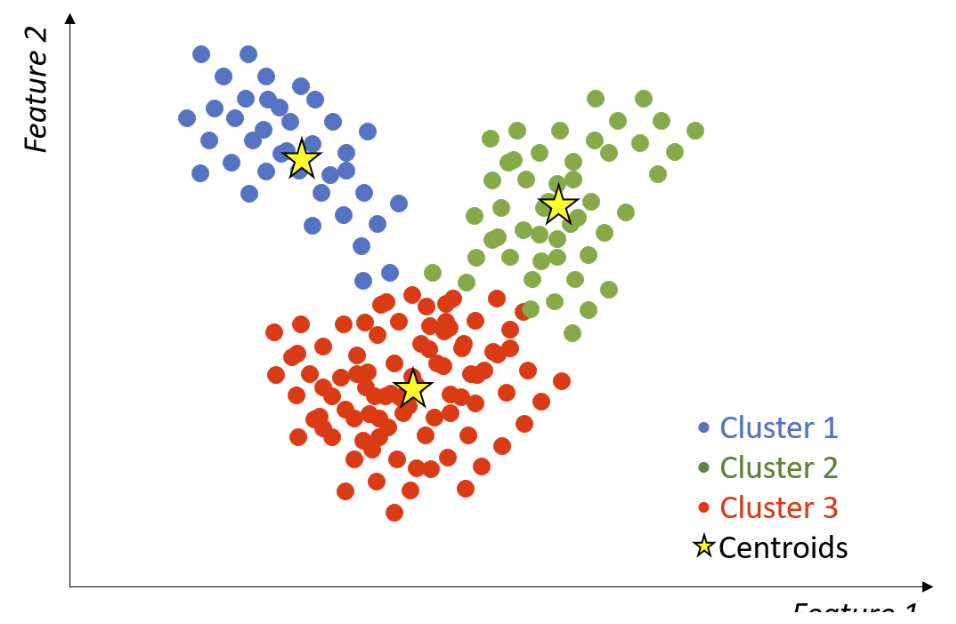

### Silhouette score
- Measures clustering's quality
- Ranges from -1 to 1
    - 1 -> well-separated
    - -1 -> points incorrectly assigned

### Feature Impact on cluster quality
- Initial a cluster at dataset with all features (F1, F2)
- Remove 1 feature at a time and retrain the model (F1)

$Impact(f2) = silhouette(f1, f2) - silhouette(f1)$

- $Impact(f) >$ 0 -> positive  contribution for f, f is important
- $Impact(f) <$ 0 -> negative contribution for f, introduces noise and may be worth removing
the impact is calculated by the different between silhouette score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

kmeans = KMeans(n_clusters=2).fix(X)
original_score = silhouette_score(X, kmeans.labels_)

for i in range(X.shape[1]):
    X_reduced = np.delete(X, i, axis=1)
    kmeans.fit(X_reduced)
    new_score = silhouette_score(X_reduced, kmeans.labels_)
    impact = original_score - new_score
    print(f"Feature {column_names[i]} has an impact of {impact}")


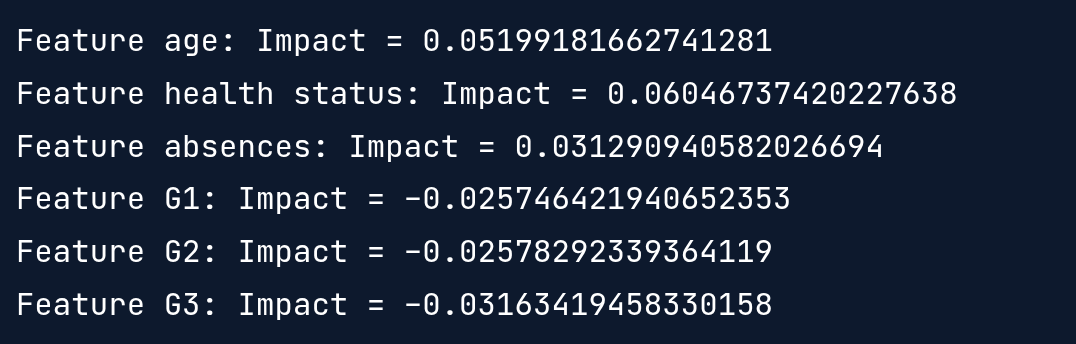
- As shown on the image above, 'age', 'health' and 'absences' are the most important features to separate the clusters.
- So g1, g2 and g3 as negative impacts.

## Adjusted rand index (ARI)
- Measures how well cluster assignments match
- Maximum ARI = 1 -> perfect cluster alignment
- Lower ARI -> greater difference  in clusterings


### Computing ARI
- Remove features one at a time
$Importance(f) = 1 - ARI(originalcluster, modifiedcluster)$
- $Low(ARI)$ -> $high(1 - ARI)$ -> important feature

In [1]:
from sklearn.metrics import adjusted_rand_score

In [ ]:
kmeans = KMeans(n_clusters=2).fit(X)
original_cluster = kmeans.predict(X,)

for i in range(X.shape[1]):
    X_reduced = np.delete(X, i , axis=1)
    reduced_clusters = kmeans.fit_predict(X_reduced)
    importance = 1 - adjusted_rand_score(original_cluster, reduced_clusters)
    print(f'{df.columns[i]}: {importance}')


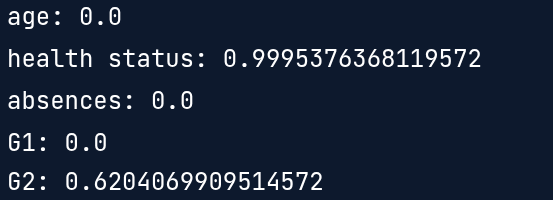